В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [64]:
!pip install opendatasets --upgrade --quiet

In [65]:
import opendatasets as od
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from google.colab import drive

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc
)


pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [66]:
def value_counts_of_column(df, column, n=5):
  print(f"______Підрахунок значень колонки {column}______\n")

  value_counts = df[column].value_counts().sort_values(ascending=False).head(n)
  value_counts_norm = df[column].value_counts(normalize=True).sort_values(ascending=False).head(n) * 100

  print(f'Топ {n} значень:\n')
  print(f"{'Значення':<10} | {'Кількість':>10} | {'Відсоток':>8}")
  print('-' * 36)
  for value in value_counts.index:
    print(f"{str(value):<10} | {str(value_counts[value]):>10} | {value_counts_norm[value]:>7.2f}%")


def describe_columns_summary(df, top_n=5):
    print(f"{'column':<18} | {'dtype':<10} | {'unique val':<10} | {'missing':<8} | {'examples'}")
    print('-' * 90)

    for col in df.columns:
        dtype = df[col].dtype
        unique_vals = df[col].dropna().unique()
        n_missing = df[col].isna().sum()
        examples = ', '.join([str(val) for val in unique_vals[:top_n]])
        print(f"{col:<18} | {str(dtype):<10} | {len(unique_vals):<10} | {n_missing:<8} | [{examples}]")

    object_columns = df.select_dtypes(include='object').columns
    numeric_columns = df.select_dtypes(include='number').columns

    print('-' * 90)
    print(f"Numeric columns: {len(numeric_columns)}     Categorical columns: {len(object_columns)}")


def binary_encode_column(df, column_name, reference_value, new_column_name=None):

    if new_column_name is None:
        new_column_name = column_name + '_Code'

    df[new_column_name] = (df[column_name] == reference_value).astype(int)
    return df


In [67]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3/data'

In [68]:
od.download(dataset_url)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-3" (use force=True to force download)


In [69]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-3'

os.listdir(data_dir)

['train.csv', 'sample_submission.csv', 'test.csv']

In [70]:
train_csv = data_dir + '/train.csv'
test_csv =  data_dir + '/test.csv'
sample_submission_csv =  data_dir + '/sample_submission.csv'

raw_df = pd.read_csv(train_csv, index_col='id')
raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.00,Nwankwo,678.00,France,Male,29.00,4.00,0.00,3.00,1.00,0.00,180626.36,0.00
1,15650086.00,Ch'in,687.00,France,Female,34.00,1.00,0.00,2.00,0.00,1.00,63736.17,0.00
2,15733602.00,Thompson,682.00,France,Female,52.00,6.00,0.00,3.00,0.00,0.00,179655.87,1.00
3,15645794.00,Macleod,753.00,Germany,Male,44.00,6.00,83347.25,2.00,1.00,0.00,161407.48,0.00
4,15633840.00,Hsia,544.00,Germany,Female,55.00,0.00,107747.57,1.00,1.00,0.00,176580.86,1.00


In [71]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       15000 non-null  float64
 1   Surname          15000 non-null  object 
 2   CreditScore      15000 non-null  float64
 3   Geography        15000 non-null  object 
 4   Gender           15000 non-null  object 
 5   Age              15000 non-null  float64
 6   Tenure           15000 non-null  float64
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  float64
 9   HasCrCard        15000 non-null  float64
 10  IsActiveMember   15000 non-null  float64
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           15000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.6+ MB


In [72]:
value_counts_of_column(raw_df, 'Exited')

______Підрахунок значень колонки Exited______

Топ 5 значень:

Значення   |  Кількість | Відсоток
------------------------------------
0.0        |      11948 |   79.65%
1.0        |       3052 |   20.35%


In [73]:
train_df, val_df = train_test_split(raw_df, test_size=0.25, random_state=42, stratify=raw_df['Exited'])

print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)

train_df.shape : (11250, 13)
val_df.shape : (3750, 13)


In [74]:
value_counts_of_column(train_df, 'Exited')

______Підрахунок значень колонки Exited______

Топ 5 значень:

Значення   |  Кількість | Відсоток
------------------------------------
0.0        |       8961 |   79.65%
1.0        |       2289 |   20.35%


In [75]:
value_counts_of_column(val_df, 'Exited')

______Підрахунок значень колонки Exited______

Топ 5 значень:

Значення   |  Кількість | Відсоток
------------------------------------
0.0        |       2987 |   79.65%
1.0        |        763 |   20.35%


**Спостереження:**

завдяки параметру stratify вдалось розбити дані так, щоб мітки були рівномірно (зберігаючи пропорцію значень) представлені у тренувальному і валідаційному наборах

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [76]:
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
input_cols, target_col

(['Surname',
  'CreditScore',
  'Geography',
  'Gender',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 'Exited')

In [77]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [78]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [79]:
print('train_inputs.shape :', train_inputs.shape)
print('train_targets.shape :', train_targets.shape)

print('val_inputs.shape :', val_inputs.shape)
print('val_targets.shape :', val_targets.shape)

train_inputs.shape : (11250, 11)
train_targets.shape : (11250,)
val_inputs.shape : (3750, 11)
val_targets.shape : (3750,)


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [80]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [81]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 ['Surname', 'Geography', 'Gender'])

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби

  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)

  2) має бути виконана принаймні одна дія передобробки

  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки.
  Для чого ви його робите?
  
  По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [82]:
describe_columns_summary(train_inputs)

column             | dtype      | unique val | missing  | examples
------------------------------------------------------------------------------------------
Surname            | object     | 720        | 0        | [Toscani, Kuo, Ejimofor, Onochie, Chukwuemeka]
CreditScore        | float64    | 372        | 0        | [696.0, 632.0, 679.0, 705.0, 581.0]
Geography          | object     | 3          | 0        | [France, Germany, Spain]
Gender             | object     | 2          | 0        | [Male, Female]
Age                | float64    | 55         | 0        | [32.0, 22.0, 48.0, 35.0, 34.0]
Tenure             | float64    | 11         | 0        | [5.0, 4.0, 3.0, 7.0, 8.0]
Balance            | float64    | 2756       | 0        | [130627.66, 119825.75, 0.0, 101070.69, 148874.01]
NumOfProducts      | float64    | 4          | 0        | [1.0, 2.0, 3.0, 4.0]
HasCrCard          | float64    | 2          | 0        | [1.0, 0.0]
IsActiveMember     | float64    | 2          | 0        | 

**Спостереження та план дій:**

- в тренувальному наборі вхідних даних - 3 категоріальних та 8 числових стовпців
- Числові колонки:
  * HasCrCard, IsActiveMember є бінарними колонками - виключаються при нормалізації (так як вже готові до завантаження в модель)
  * у звязку з розкидом значень від малих (NumOfProducts, Tenure) до великих (EstimatedSalary, Balance) я б масштабував числові дані для виключення надмірного впливу ознак з великим розкидом значень.
- Категоріальні колонки:
  * Geography, Gender можна закодувати за допомогою OneHotEncoding (всього 3 та 2 категоріальних значення)
  * Gender я спочатку закондував з бінарним значенням, але потім вийшли нестиковки в останніх завданнях з роботою з raw_df, тому переробив
  * Surname - поки що мені бракує знань як кодувати, тому пропоную випустити колонку. Але в майбутньому я б подивився чи можна згрупувати прізвища та чи є кореляція між групами та таргетом
- Пропущених значень немає.


**Видалимо зі списку категоріальних колонок Surname**

In [83]:
categorical_cols.remove('Surname')
categorical_cols

['Geography', 'Gender']

**Розділимо числові колонки на бінарні та багатозначні числові**

In [84]:
binary_numeric_cols = [col for col in numeric_cols if train_inputs[col].nunique() == 2]
numeric_cols_cleaned = [col for col in numeric_cols if col not in binary_numeric_cols]
binary_numeric_cols, numeric_cols_cleaned

(['HasCrCard', 'IsActiveMember'],
 ['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'EstimatedSalary'])

In [85]:
train_inputs[numeric_cols_cleaned].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,11250.00,11250.00,11250.00,11250.00,11250.00,11250.00
mean,658.99,37.69,5.02,42952.89,1.59,117904.96
std,72.12,8.14,2.78,59923.39,0.53,45553.03
min,431.00,18.00,0.00,0.00,1.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,83155.87
50%,661.00,37.00,5.00,0.00,2.00,123587.95
75%,709.00,42.00,7.00,109863.19,2.00,156774.94
max,850.00,72.00,10.00,209767.31,4.00,199992.48


**Масштабуємо числові колонки**

In [86]:
scaler = StandardScaler().fit(train_inputs[numeric_cols_cleaned])
train_inputs[numeric_cols_cleaned] = scaler.transform(train_inputs[numeric_cols_cleaned])
val_inputs[numeric_cols_cleaned] = scaler.transform(val_inputs[numeric_cols_cleaned])

**Категоріальні колонки закодуємо за допомогою OneHotEncoding**

In [87]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [88]:
display(train_inputs.head(), val_inputs.head())

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,,,,
8263,Toscani,0.51,France,Male,-0.70,-0.01,1.46,-1.11,1.00,1.00,-0.68,1.00,0.00,0.00,0.00,1.00
14199,Kuo,-0.37,Germany,Female,-0.70,-0.37,1.28,-1.11,1.00,0.00,1.31,0.00,1.00,0.00,1.00,0.00
1856,Ejimofor,0.28,France,Female,-1.93,-0.37,-0.72,0.77,1.00,1.00,0.98,1.00,0.00,0.00,1.00,0.00
3013,Onochie,0.64,France,Male,1.27,-0.73,-0.72,0.77,1.00,0.00,0.04,1.00,0.00,0.00,0.00,1.00
8266,Chukwuemeka,0.51,France,Female,-0.33,0.71,-0.72,0.77,1.00,0.00,-0.38,1.00,0.00,0.00,1.00,0.00


,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,,,,
1855,Bitter,-1.61,France,Male,-1.07,1.43,1.28,-1.11,0.00,0.00,-1.36,1.00,0.00,0.00,0.00,1.00
1273,Ting,-0.85,Germany,Male,0.41,-0.73,1.35,-1.11,1.00,0.00,1.29,0.00,1.00,0.00,0.00,1.00
5414,Maclean,-0.53,France,Male,-0.82,0.71,-0.72,-1.11,1.00,1.00,0.71,1.00,0.00,0.00,0.00,1.00
10923,Chiang,-0.86,France,Male,2.25,-0.73,-0.72,4.53,1.00,0.00,-0.33,1.00,0.00,0.00,0.00,1.00
5835,Oluchi,1.25,Spain,Female,0.53,-0.01,-0.72,-1.11,1.00,1.00,1.40,0.00,0.00,1.00,1.00,0.00


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [89]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
dir = "/content/drive/MyDrive/ML/MLFH 3.0/data/kaggle/competitions/bank-customer-churn-prediction/"
os.listdir(dir)

['train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

In [91]:
train_inputs.to_parquet('train_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [92]:
os.listdir(dir)

['train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхідних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [93]:
X_train = train_inputs[numeric_cols_cleaned + binary_numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols_cleaned + binary_numeric_cols + encoded_cols]

In [94]:
display(X_train.head(), X_val.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,
8263,0.51,-0.70,-0.01,1.46,-1.11,-0.68,1.00,1.00,1.00,0.00,0.00,0.00,1.00
14199,-0.37,-0.70,-0.37,1.28,-1.11,1.31,1.00,0.00,0.00,1.00,0.00,1.00,0.00
1856,0.28,-1.93,-0.37,-0.72,0.77,0.98,1.00,1.00,1.00,0.00,0.00,1.00,0.00
3013,0.64,1.27,-0.73,-0.72,0.77,0.04,1.00,0.00,1.00,0.00,0.00,0.00,1.00
8266,0.51,-0.33,0.71,-0.72,0.77,-0.38,1.00,0.00,1.00,0.00,0.00,1.00,0.00


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,HasCrCard,IsActiveMember,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
id,,,,,,,,,,,,,
1855,-1.61,-1.07,1.43,1.28,-1.11,-1.36,0.00,0.00,1.00,0.00,0.00,0.00,1.00
1273,-0.85,0.41,-0.73,1.35,-1.11,1.29,1.00,0.00,0.00,1.00,0.00,0.00,1.00
5414,-0.53,-0.82,0.71,-0.72,-1.11,0.71,1.00,1.00,1.00,0.00,0.00,0.00,1.00
10923,-0.86,2.25,-0.73,-0.72,4.53,-0.33,1.00,0.00,1.00,0.00,0.00,0.00,1.00
5835,1.25,0.53,-0.01,-0.72,-1.11,1.40,1.00,1.00,0.00,0.00,1.00,1.00,0.00


In [95]:
model = LogisticRegression(solver='saga', max_iter=500)
model.fit(X_train, train_targets)

LogisticRegression(max_iter=500, solver='saga')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [96]:
def predict_and_evaluate_model(model, inputs, targets, name=''):

    y_pred_proba = model.predict_proba(inputs)[:, 1]
    y_preds = (y_pred_proba >= 0.5).astype(int)

    accuracy = accuracy_score(targets, y_preds)
    print(f"{name} Accuracy: {100*accuracy:.2f}%")

    f1 = f1_score(targets, y_preds)
    print(f"{name} F1 score: {100*f1:.2f}%")

    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"{name} AUROC: {roc_auc:.3f}")

    cf_matrix = confusion_matrix(targets, y_preds, normalize='true')
    plt.figure(figsize=(6, 4))
    sns.heatmap(cf_matrix, annot=True, fmt='.2f')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()

    return y_preds

Training Accuracy: 87.49%
Training F1 score: 64.19%
Training AUROC: 0.883


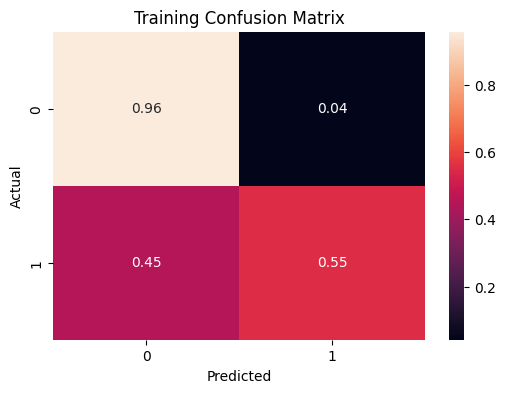

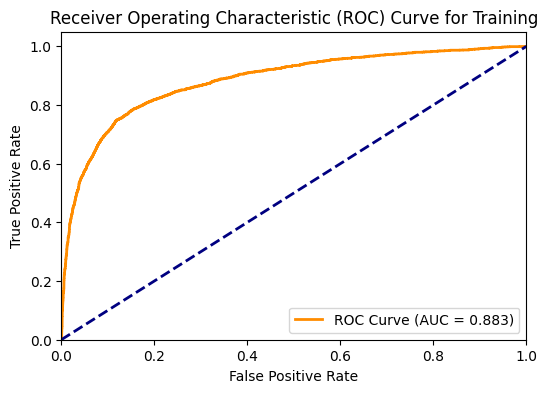

In [97]:
train_preds = predict_and_evaluate_model(model, X_train, train_targets, 'Training')

Validation Accuracy: 87.09%
Validation F1 score: 63.83%
Validation AUROC: 0.880


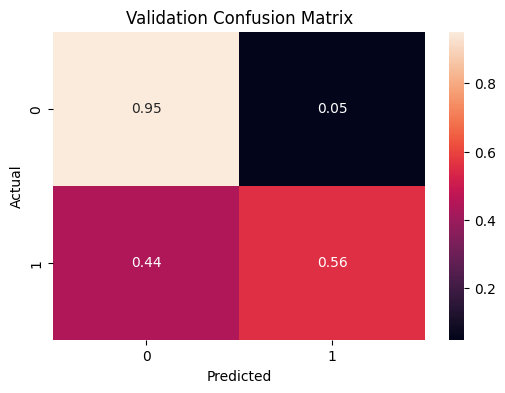

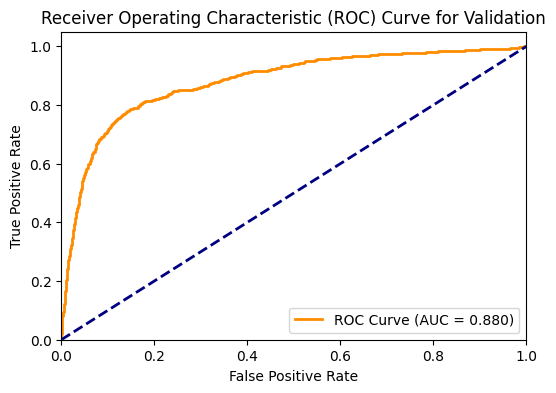

In [98]:
val_preds = predict_and_evaluate_model(model, X_val, val_targets, 'Validation')

**Спостереження:**

- **AUROC >= 0.88** — модель доволі непогано розрізняє класи, що є хорошим показником.

- **F1 Score ≈ 0.64** — баланс між точністю та повнотою **на задовільному рівні**.

- **Confusion Matrix** показує, що модель **робить помилки**, але **в межах допустимого** (особливо якщо враховувати незбалансованість класів).

- **Немає ознак переобучення**: показники на тренувальному та валідаційному наборах подібні.

**Висновок:**

Загальна якість моделі — доволі хороша. Вона готова до подальшого використання або тонкого налаштування.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [99]:
value_counts_of_column(train_df, 'Exited')

______Підрахунок значень колонки Exited______

Топ 5 значень:

Значення   |  Кількість | Відсоток
------------------------------------
0.0        |       8961 |   79.65%
1.0        |       2289 |   20.35%


In [100]:
def predict_no_exited(inputs):
    return np.full(len(inputs), 0)

In [101]:
model_train_accuracy = accuracy_score(train_targets, train_preds)
model_val_accuracy = accuracy_score(val_targets, val_preds)

no_exited_train_accuracy = accuracy_score(train_targets, predict_no_exited(train_inputs))
no_exited_val_accuracy = accuracy_score(val_targets, predict_no_exited(val_inputs))

In [102]:
print(f"Model - train acc.: {100*model_train_accuracy:.2f}%")
print(f"Model - val acc.: {100*model_val_accuracy:.2f}%")
print(f"Major Class - train acc.: {100*no_exited_train_accuracy:.2f}%")
print(f"Major Class - val acc.: {100*no_exited_val_accuracy:.2f}%")

Model - train acc.: 87.49%
Model - val acc.: 87.09%
Major Class - train acc.: 79.65%
Major Class - val acc.: 79.65%


**Спостереження:**

- Натренована модель демонструє покращену ефективність порівняно з базовою моделлю, яка завжди передбачає мажоритарний клас:
  * на тренувальному наборі точність вища на 7.84 % п.
  * на валідаційному - на 7.44 % п.

- Різниця між точністю моделі на тренувальному (87.49%) та валідаційному (87.09%) наборах є невеликою (0.4 відсоткового пункту). Це свідчить про те, що модель добре узагальнює і не перенавчається на тренувальних даних.

**Висновок:**

Загалом, натренована модель успішно вивчає закономірності в даних і робить  точніші передбачення, ніж просте припущення мажоритарного класу. Тобто модель має реальну передбачувальну цінність для вирішення задачі. Але є місце для тонкого налаштування і покращення точності.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [103]:
bank_customer_churn_prediction = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols_cleaned': numeric_cols_cleaned,
    'binary_numeric_cols': binary_numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

joblib.dump(bank_customer_churn_prediction, 'log_reg.joblib')

['log_reg.joblib']

In [104]:
loaded_data = joblib.load('log_reg.joblib')

model_2 = loaded_data['model']

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [105]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols_cleaned, binary_numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols_cleaned] = scaler.transform(input_df[numeric_cols_cleaned])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols_cleaned + binary_numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [106]:
predict_raw_df(scaler, encoder, numeric_cols_cleaned, binary_numeric_cols, categorical_cols, raw_df[:10])

array([0.00550784, 0.0336398 , 0.37791831, 0.37988571, 0.97927108,
       0.02627622, 0.13087651, 0.01209286, 0.97681122, 0.04162818])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [107]:
test_raw_df = pd.read_csv(test_csv,index_col='id')
test_raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,,,,,,,,,,,,
15000,15594796.00,Chu,584.00,Germany,Male,30.00,2.00,146053.66,1.00,1.00,1.00,157891.86
15001,15642821.00,Mazzi,551.00,France,Male,39.00,5.00,0.00,2.00,1.00,1.00,67431.28
15002,15716284.00,Onyekachi,706.00,France,Male,43.00,8.00,0.00,2.00,1.00,0.00,156768.45
15003,15785078.00,Martin,717.00,Spain,Male,45.00,3.00,0.00,1.00,1.00,1.00,166909.87
15004,15662955.00,Kenechukwu,592.00,Spain,Male,43.00,8.00,0.00,2.00,1.00,1.00,143681.97


In [108]:
exited_predicts = predict_raw_df(scaler, encoder, numeric_cols_cleaned, binary_numeric_cols, categorical_cols, test_raw_df)
test_raw_df['Exited'] = exited_predicts
test_raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
id,,,,,,,,,,,,,,,,,,
15000,15594796.00,Chu,-1.04,Germany,Male,-0.94,-1.09,1.72,-1.11,1.00,1.00,0.88,0.00,1.00,0.00,0.00,1.00,0.07
15001,15642821.00,Mazzi,-1.50,France,Male,0.16,-0.01,-0.72,0.77,1.00,1.00,-1.11,1.00,0.00,0.00,0.00,1.00,0.03
15002,15716284.00,Onyekachi,0.65,France,Male,0.65,1.07,-0.72,0.77,1.00,0.00,0.85,1.00,0.00,0.00,0.00,1.00,0.15
15003,15785078.00,Martin,0.80,Spain,Male,0.90,-0.73,-0.72,-1.11,1.00,1.00,1.08,0.00,0.00,1.00,0.00,1.00,0.20
15004,15662955.00,Kenechukwu,-0.93,Spain,Male,0.65,1.07,-0.72,0.77,1.00,1.00,0.57,0.00,0.00,1.00,0.00,1.00,0.05


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [109]:
sample_submission_df = pd.read_csv(sample_submission_csv, index_col='id')
sample_submission_df.head()

,Exited
id,
15000,0.50
15001,0.50
15002,0.50
15003,0.50
15004,0.50


In [110]:
sample_submission_df['Exited'] = exited_predicts
sample_submission_df.head()

,Exited
id,
15000,0.07
15001,0.03
15002,0.15
15003,0.20
15004,0.05


In [111]:
sample_submission_df.to_csv('submission_log_reg.csv')